DATA TAKSI ONLINE
   Jarak_Km  Biaya_Ribu
0         1          12
1         2          15
2         3          18
3         4          21
4         5          24
5         6          27
6         7          30
7         8          33
8         9          36
9        10          39

DESKRIPSI DATASET
Jumlah data: 10
Fitur (X): Jarak Tempuh (km)
Target (y): Biaya (ribu rupiah)

Statistik:
       Jarak_Km  Biaya_Ribu
count  10.00000   10.000000
mean    5.50000   25.500000
std     3.02765    9.082951
min     1.00000   12.000000
25%     3.25000   18.750000
50%     5.50000   25.500000
75%     7.75000   32.250000
max    10.00000   39.000000


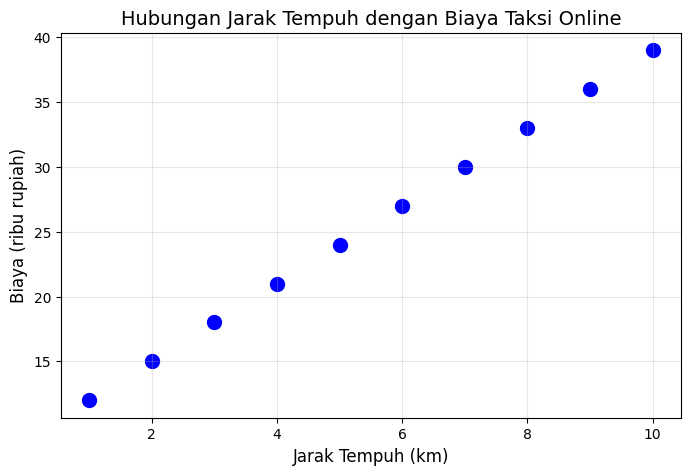


SPLIT DATA
Data training: 8 sampel
Data testing: 2 sampel

HASIL MODEL
Intercept (θ₀): 9.00
Slope (θ₁): 3.00

Persamaan garis regresi:
Biaya = 9.00 + 3.00 × Jarak

HASIL PREDIKSI
   Jarak_Km  Biaya_Aktual  Biaya_Prediksi  Error
8         9            36            36.0    0.0
1         2            15            15.0    0.0

EVALUASI MODEL
R² Score: 1.0000
Mean Squared Error (MSE): 0.00

✅ R² > 0.9 → Model sangat baik!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


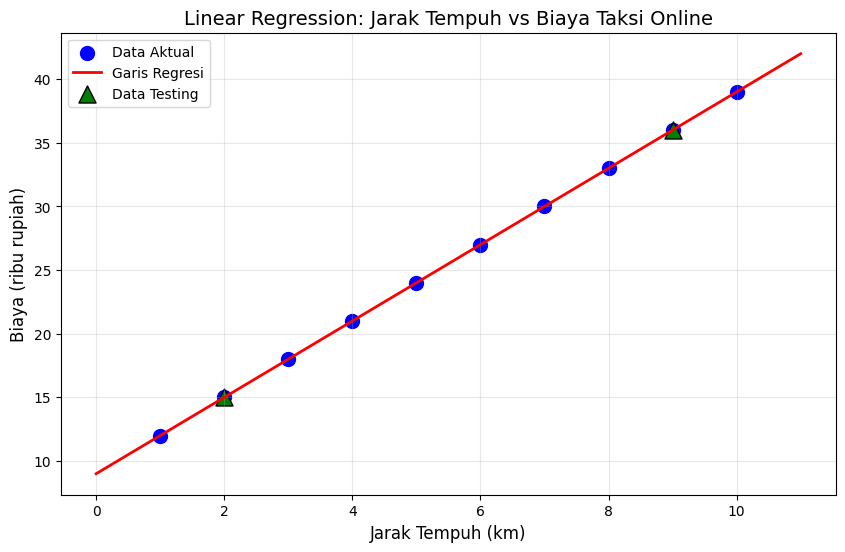

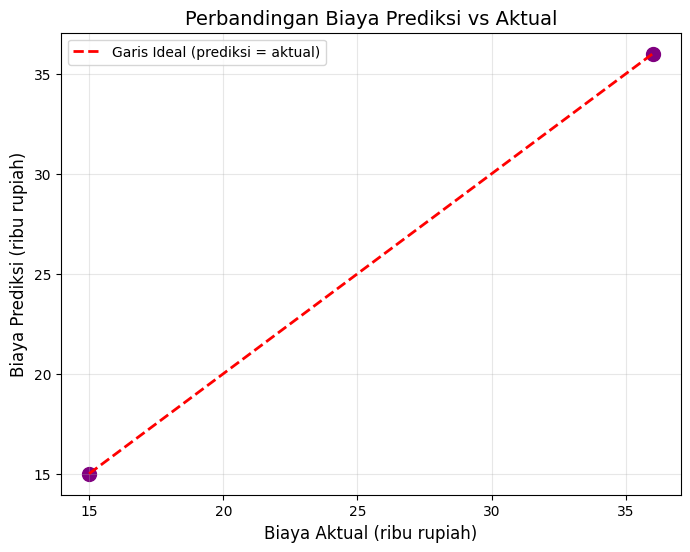


ANALISIS DAN KESIMPULAN

1. INTERPRETASI SLOPE DAN INTERCEPT:
   - Intercept (θ₀ = 9.00):
     Artinya: Jika jarak tempuh 0 km (belum jalan), 
     biaya tetap yang dikenakan adalah Rp 9.000 (biaya buka pintu).
   
   - Slope (θ₁ = 3.00):
     Artinya: Setiap penambahan 1 km jarak tempuh, 
     biaya bertambah Rp 3.000.

2. PERFORMAMODEL:
   - R² Score = 1.0000:
     Artinya 100% variasi biaya dapat dijelaskan oleh jarak tempuh.
     Model sempurna karena data memang linear sempurna.
   
   - MSE = 0.00:
     Tidak ada error karena data fit sempurna dengan garis.

3. APAKAH ADA OVERFITTING ATAU UNDERFITTING?
   - Tidak ada overfitting: Model linear sederhana tidak mungkin overfit.
   - Tidak ada underfitting: R² sempurna menunjukkan model sangat baik.

4. KESIMPULAN:
   Model Linear Regression berhasil memprediksi biaya taksi online
   berdasarkan jarak tempuh dengan akurasi sempurna.
   Hubungan keduanya adalah linear positif dengan rumus:
   
   >>> Biaya = 9.000 + 3.000 × Jarak (km

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
data = {
    'Jarak_Km': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Biaya_Ribu': [12, 15, 18, 21, 24, 27, 30, 33, 36, 39]
}

df = pd.DataFrame(data)

print("="*50)
print("DATA TAKSI ONLINE")
print("="*50)
print(df)

print("\n" + "="*50)
print("DESKRIPSI DATASET")
print("="*50)
print(f"Jumlah data: {len(df)}")
print(f"Fitur (X): Jarak Tempuh (km)")
print(f"Target (y): Biaya (ribu rupiah)")
print("\nStatistik:")
print(df.describe())

plt.figure(figsize=(8,5))
plt.scatter(df['Jarak_Km'], df['Biaya_Ribu'], color='blue', s=100)
plt.xlabel('Jarak Tempuh (km)', fontsize=12)
plt.ylabel('Biaya (ribu rupiah)', fontsize=12)
plt.title('Hubungan Jarak Tempuh dengan Biaya Taksi Online', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

X = df[['Jarak_Km']]
y = df['Biaya_Ribu']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n" + "="*50)
print("SPLIT DATA")
print("="*50)
print(f"Data training: {len(X_train)} sampel")
print(f"Data testing: {len(X_test)} sampel")

model = LinearRegression()
model.fit(X_train, y_train)

print("\n" + "="*50)
print("HASIL MODEL")
print("="*50)
slope = model.coef_[0]
intercept = model.intercept_
print(f"Intercept (θ₀): {intercept:.2f}")
print(f"Slope (θ₁): {slope:.2f}")
print(f"\nPersamaan garis regresi:")
print(f"Biaya = {intercept:.2f} + {slope:.2f} × Jarak")

y_pred = model.predict(X_test)

print("\n" + "="*50)
print("HASIL PREDIKSI")
print("="*50)
hasil_prediksi = pd.DataFrame({
    'Jarak_Km': X_test['Jarak_Km'],
    'Biaya_Aktual': y_test,
    'Biaya_Prediksi': y_pred,
    'Error': y_test - y_pred
})
print(hasil_prediksi)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("\n" + "="*50)
print("EVALUASI MODEL")
print("="*50)
print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")

if r2 > 0.9:
    print("\n✅ R² > 0.9 → Model sangat baik!")
elif r2 > 0.7:
    print("\n✅ R² > 0.7 → Model cukup baik")
else:
    print("\n⚠️ R² rendah → Model perlu perbaikan")

plt.figure(figsize=(10,6))

plt.scatter(X, y, color='blue', s=100, label='Data Aktual')

X_range = [[i] for i in range(0, 12)]
y_range = model.predict(X_range)
plt.plot(X_range, y_range, color='red', linewidth=2, label='Garis Regresi')

plt.scatter(X_test, y_test, color='green', s=150, marker='^',
            label='Data Testing', edgecolors='black')

plt.xlabel('Jarak Tempuh (km)', fontsize=12)
plt.ylabel('Biaya (ribu rupiah)', fontsize=12)
plt.title('Linear Regression: Jarak Tempuh vs Biaya Taksi Online', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='purple', s=100)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Garis Ideal (prediksi = aktual)')
plt.xlabel('Biaya Aktual (ribu rupiah)', fontsize=12)
plt.ylabel('Biaya Prediksi (ribu rupiah)', fontsize=12)
plt.title('Perbandingan Biaya Prediksi vs Aktual', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "="*50)
print("ANALISIS DAN KESIMPULAN")
print("="*50)
print("""
""")

1. INTERPRETASI SLOPE DAN INTERCEPT:
   - Intercept (θ₀ = 9.00):
     Artinya: Jika jarak tempuh 0 km (belum jalan),
     biaya tetap yang dikenakan adalah Rp 9.000 (biaya buka pintu).
   
   - Slope (θ₁ = 3.00):
     Artinya: Setiap penambahan 1 km jarak tempuh,
     biaya bertambah Rp 3.000.

2. PERFORMAMODEL:
   - R² Score = 1.0000:
     Artinya 100% variasi biaya dapat dijelaskan oleh jarak tempuh.
     Model sempurna karena data memang linear sempurna.
   
   - MSE = 0.00:
     Tidak ada error karena data fit sempurna dengan garis.

3. APAKAH ADA OVERFITTING ATAU UNDERFITTING?
   - Tidak ada overfitting: Model linear sederhana tidak mungkin overfit.
   - Tidak ada underfitting: R² sempurna menunjukkan model sangat baik.

4. KESIMPULAN:
   Model Linear Regression berhasil memprediksi biaya taksi online
   berdasarkan jarak tempuh dengan akurasi sempurna.
   Hubungan keduanya adalah linear positif dengan rumus:
   
   >>> Biaya = 9.000 + 3.000 × Jarak (km) <<<
   
   Contoh: Jarak 5 km → Biaya = 9.000 + 3.000×5 = Rp 24.000
"""